In [1]:
#hidden cell to be executed BEFORE the presentation
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import dftpy
from dftpy.ions import Ions
from dftpy.field import DirectField
from dftpy.grid import DirectGrid
from dftpy.functional import LocalPseudo, Functional, TotalFunctional
from dftpy.formats import io
from dftpy.math_utils import ecut2nr
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.mpi import sprint
from IPython.lib.display import YouTubeVideo
from IPython.display import IFrame
from ase.visualize import view
PP_list = {'Al': 'Al_lda.oe01.recpot'}
#import fortecubeview

In [4]:
from IPython.display import IFrame
import numpy as np
import matplotlib.pyplot as plt
from ase.build import molecule
from pyscf import gto

<div id="bg-slide">
    <center>
    <h1>DFT introduction #1</h1>
<center>
<br>
<table>
  <tr>
      <td><p><h1>Team Rutgers</h1></p><p><h2>(Valeria, Aniket, Fabrizio and Michele)</h2></p></td> 
      <td><img src="../figures/logos/sudan_intro.png" width=300 height=300 /></td>
  </tr>
  <tr>
    <td></td>
    <td>An interactive session</td>
  </tr>
</table>

Retrieve this presentation on GitHub at:

https://github.com/Quantum-MultiScale-Template/DFT-Intro

[Or open this notebook directly on Google Colab](https://colab.research.google.com/github/Quantum-MultiScale-Template/DFT-Intro/blob/main/2026/sudan2026/presentation/DFT_intro_combined.ipynb)

<center>
    <img src="../figures/random/QR_Colab.png" width=350 />
</center>


<center><h3> Physics without frontiers Sudan $\bullet$ July 29, 2026</h3></center>
</div>



# Goals of this lecture

This introduction comes in three parts:

**Part 1 &mdash; Density Functional Theory**
- Why DFT; the Hohenberg&ndash;Kohn theorems; the Kohn&ndash;Sham construction
- The KS equations and the exchange&ndash;correlation functional

**Part 2 &mdash; Basis sets** (briefly)
- What a basis set is, and how it turns the KS equations into $\mathbb{HC=SC\varepsilon}$

**Part 3 &mdash; Solving self-consistently (the SCF cycle)**
- Occupations (aufbau and smearing)
- The Self-Consistent Field loop, and how to run it in QEpy / QE

# Split into `N` groups

 - Assign number `1-N` to each student
 - Groups sit together
 - Possibly have 1 instructor per group

# The Real World
<table>
    <tr>
      <td><h3>Photocatalyst</h3></td>
        <td><h3>Catalytic nanoparticles</h3></td>
  </tr>
  <tr>
      <td><img src="../figures/science/photocatalyst.png" height=500 /></td>
      <td><img src="../figures/science/catalyst.png" height=500 /></td>
  </tr>
    <tr>
        <td>Chem. Comm., 43, 6551 (2009)</td>
        <td>PCCP, 21, 15080 (2019)</td>
    </tr>
</table>   

# Available electronic structure methods
<br>
<center>
    <img src="../figures/science/electronic_structure.png" width=1600 />
</center>

# Challenge 1

[Let's check your QM knowledge.](https://forms.cloud.microsoft/r/GwpcP6DPH8) 
- What is the molecular Hamiltonian?

<center>
    <img src="../figures/random/QR_Challenge1.png" width=350 />
</center>


# Solution to Challenge #1 and a bit more...

Molecular Hamiltonian for interacting electrons and nuclei of charge $Z_\alpha$

$$
\hat{H} = \underbrace{-\frac{1}{2}\sum_i^{N_e} \nabla^2_i}_{\hat T} + \underbrace{\sum_i^{N_e}\sum_\alpha^{N_n} \frac{-Z_\alpha}{|r_i-R_\alpha|}}_{\hat V_{eN}} + \underbrace{\frac{1}{2}\sum_{i\neq j}^{N_e} \frac{1}{|r_i-r_j|}}_{\hat V_{ee}} + E_{NN}
$$

The Schrödinger equation for the ground state of the interacting system

$$
\hat H \Psi_0 = E_0 \Psi_0
$$

Expectation values of each term of the Hamiltonian

$$
T[\Psi_0] = \langle \Psi_0 | \hat T | \Psi_0 \rangle, ~~ E_{ee}[\Psi_0] = \langle \Psi_0 | \hat V_{ee} | \Psi_0 \rangle
$$

$$
E_{eN}[\Psi_0] = \color{red}{E_{eN}[n]} = \langle \Psi_0 | \hat V_{eN} | \Psi_0 \rangle = \int n(r) v_{eN}(r) dr
$$

# The Hohenberg and Kohn theorems
<br>
<br>
$$
\Psi_0 \longleftrightarrow n(r) \longleftrightarrow v_{eN}(r) \longleftrightarrow \Psi_0 
$$

Therefore $n(r)$, $v_{eN}(r)$ or $\Psi_0$ hold the same information. 

[HK paper 1964](../papers/PhysRev.136.B864.pdf)

In particular:

$$
E \equiv E[\Psi_0] \equiv E[v_{eN}] \equiv E[n]
$$

DFT exploits the latter as follows:

<center>
    <div class="alert alert-success"> 
    $$
     E[n] = T[n] + E_{ee}[n]+E_{eN}[n]+E_{NN}
    $$
    </div> 
</center>

# Challenge 2

[What do the energy functionals mean?](https://forms.cloud.microsoft/r/K7y9YswVJ0) 
- Write an expression for each of the functionals ($T$, $E_{ee}$, $E_{eN}$) in terms of $n(r)$ and/or of $\Psi_0$.

<center>
    <img src="../figures/random/QR_Challenge2.png" width=350 />
</center>


# Solution to Challenge #2 and a bit more...

Recalling:
$$
\color{red}{E_{eN}[n]} = \langle \Psi_0 | \hat V_{eN} | \Psi_0 \rangle = \int n(r) v_{eN}(r) dr
$$
<center>
    <div class="alert alert-success"> 
    Because $v_{eN}$ is fixed by the system's geometry, $E_{eN}$ is already a density functional.
    </div> 
</center>

For the other terms in the Hamiltonian:
<br>
<br>
<br>

$$
T[\Psi_0] = \langle \Psi_0 | \hat T | \Psi_0 \rangle, ~~ E_{ee}[\Psi_0] = \langle \Psi_0 | \hat V_{ee} | \Psi_0 \rangle
$$
<br>
<br>

<center>
    <div class="alert alert-danger"> 
        Apparently, $T$ and $E_{ee}$ <b>cannot</b> be written as denisty functionals...
    </div> 
</center>


<h1> What can we do with the HK theorems? </h1>
<br>
<br>
<center>
<span style="font-size:45pt;"><i>               $n(r)$</i></span>
</center>
<br>
<br>
<br>
<center>...the density determines everything... in principle.... but is this useful? ... Are the functionals involved known?</center>

# Introducing: the Kohn-Sham (KS) system of *noninteracting* electrons
[KS paper 1965](../papers/PhysRev.140.A1133.pdf)

<center><img src="../figures/science/ks_system.png" width=1600 /></center>

<center> The <b>density</b> of the KS system is <b>the same</b> as the interacting system.</center>

<center style="font-size:20pt;"> $~~v_s(r) \longleftrightarrow n(r) \longleftrightarrow v_{eN}(r)$ </center>
<br>
<center> The <b>external potential</b> of the KS system is <b>different</b> from the interacting system.</center>

# Energy functional for the KS system

$$
E[n] = \color{red}{T[n] + E_{ee}[n]}+E_{eN}[n]+E_{NN}
$$

<center>
    <div class="alert alert-success"> 
        $$E[n] = \color{red}{T_s[n] + E_{H}[n] + E_{xc}[n]}+ E_{eN}[n]+ E_{NN}$$
        <br>
        where the density $n(r) = \sum_i^N |\phi_i(r)|^2$.
    </div> 
</center>

The KS kinetic energy is

$$
T_{s}[n] \equiv T_s[\{\phi_i\}]=  -\frac{1}{2}\sum_i \langle \phi_i | \nabla^2 | \phi_i\rangle = -\frac{1}{2}\sum_i  \int \phi_i^*(r) \nabla^2 \phi_i(r) dr
$$

<span style="color: red;">Mind: $T_s \neq T$.</span>

The classical e-e repulsion (Hartree) and e-N attraction:

$$
E_H[n]=\frac{1}{2}\int \frac{n(r)n(r')}{|r-r'|}drdr' \qquad\qquad E_{eN}[n] = \int n(r) v_{eN}(r) dr
$$

# Challenge 3: What is $E_{xc}$?


[Derive an expression for $E_{xc}$](https://forms.cloud.microsoft/r/9vBghFDDR0) 
- Derive an expression for $E_{xc}$ in terms of $T$, $E_{ee}$, $T_s$ and $E_H$.

<center>
    <img src="../figures/random/QR_Challenge3.png" width=350 />
</center>



# Solution to Challenge #3

The energy functional, whether KS or interacting, should yield the same energy value, therefore

$$
E_{xc}[n] = E_{ee}[n]-E_H[n] + T[n]-T_s[n]
$$


<center>
    <div class="alert alert-success">
        $E_{xc}$ bundles the two pieces we could <b>not</b> compute exactly:<br><br>
        the <b>non-classical</b> electron-electron energy $\;(E_{ee}-E_H)\;$ (exchange $+$ correlation)<br>
        and the <b>kinetic correlation</b> $\;(T-T_s)$.
    </div>
</center>

It is a *small* fraction of the total energy &mdash; but it controls bonding, so approximating it well is everything.

# Can $E_{xc}[n]$ be approximated? 

Usually it is approached by separating exchange, $E_x$, and correlation, $E_c$:
$$
E_{xc}[n]=E_{x}[n]+E_{c}[n]
$$

<center>
    <div class="alert alert-success">
        <b>Local Density Approximation</b> from the UEG. Example from Dirac's exchange:
        $$
        E_{x}^{\rm UEG} = - c_x \bar n^{4/3} V \longrightarrow E_x[n] \simeq -c_x \int n^{4/3}(r) dr
        $$
    </div>
</center>

# Approximating $E_{xc}$: Jacob's ladder

Each rung uses more information about the density, trading cost for accuracy:

 - **LDA** &mdash; uses $n(r)$ only *(local)*
 - **GGA** &mdash; adds the gradient $\nabla n(r)$ &nbsp;(e.g. PBE)
 - **meta-GGA** &mdash; adds the kinetic-energy density $\tau(r)$ &nbsp;(e.g. SCAN)
 - **hybrids** &mdash; mix in exact (Hartree-Fock) exchange &nbsp;(e.g. PBE0, B3LYP)
 - **fully non-local** &mdash; RPA, double hybrids

<center>
    <div class="alert alert-success">
        Climbing the ladder generally buys accuracy at the price of computational cost.
    </div>
</center>

 - <b>QE<span style="color: red;">py</span></b> uses same structure as QE to specify the `xc` functional

In [1]:
qe_options = {}
qe_options["&system"] = {}
qe_options["&system"]["input_dft"] = 'LDA'

 - Typically xc is already specified in the pseudopotential files.

# Solving for the electronic structure (find the KS orbitals, $\{\phi_i\}$)

To minimize the energy, we define an appropriate Lagrangian:

$$
\mathcal{L}_{KS}[\{\phi_i\}] = E[\{\phi_i\}] - \sum_{ij} \varepsilon_{ij}\left(\langle \phi_j|\phi_i \rangle - \delta_{ij}\right)
$$

At the minimum, we impose $\frac{\delta \mathcal{L}_{KS}[\{\phi_i\}]}{\delta \langle \phi_j|}=0$ or just $\frac{\delta \mathcal{L}_{KS}[\{\phi_i\}]}{\delta \phi_j^*(r)}=0$, and choose the so-called <b>canonical</b> orbitals (i.e., $\varepsilon_{ij}=\varepsilon_{i}\delta_{ij}$).

This yields the <span style="color: green;">Kohn-Sham equations</span>:

$$
-\frac{1}{2}\nabla^2 \phi_i(r) + v_s[n](r)\phi_i(r) = \varepsilon_i\phi_i(r)
$$

where $v_s(r)$ includes effects of e-N attraction and e-e repulsion. <span style="color: red;">But what is $v_s(r)$?</span>

# Challenge 4: homework

Considering the chain rule of functional differentiation ($\phi^*$ and $\phi$ are considered independent variables):
$$
\frac{\delta F[n]}{\delta \phi_j^*(r)} = \int \frac{\delta F[n]}{\delta n(r')}\frac{\delta n(r')}{\delta \phi_j^*(r)}dr' = \frac{\delta F[n]}{\delta n(r)} \phi_j(r).
$$

<span style="color: green;">Show that the KS potential is given by:</span>

$$
\color{green}{v_s[n](r) = \frac{\delta E_{H}[n]}{\delta n(r)} + \frac{\delta E_{xc}[n]}{\delta n(r)} + v_{eN}(r)}
$$
$$
~~~~~~~~~~~~~~~~~~~~~~ \color{green}{= \int \frac{n(r')}{|r-r'|} dr' + \frac{\delta E_{xc}[n]}{\delta n(r)} + v_{eN}(r)}
$$



<div id="bg-slide">
<br><br>
<center>
<span style="font-size:34pt;"><b>Part 2</b></span>
<br><br>
<h1>Basis sets</h1>
<br>
<h3>Representing the Kohn-Sham orbitals on a computer</h3>
</center>
<br><br>
</div>

# Assumptions

 - Basic linear algebra (vectors, matrices, operators, wavefunctions)
 - Undergraduate QM
 - Dirac notation (i.e., i-th vector $\to |i\rangle$ or $|\psi_i\rangle$, scalar product between <i>i</i> and <i>j</i> $\to \langle \psi_i | \psi_j\rangle$)
 - Kohn-Sham equations

# Why are basis sets needed?

 - They provide a representation
 - Allow us to discretize the problem

# Let's expand a function in a basis

$$
\psi_k(r) = \sum_i C_{ik} \chi_i(r)
$$

 - $\{\chi_i(r)\}$ are basis functions forming a <b>basis set</b>
 - $\{C_{ik}\}$ are expansion coefficients, $C_{ik}\in \mathbb{C}$

# The idea, by analogy

 - Any **vector** is a sum of components along basis vectors $\hat e_i$.
 - Any **signal** is a sum of pure tones (Fourier).
 - Any **orbital** $\psi_k(r)$ is a weighted sum of fixed building blocks $\chi_i(r)$.

<center>
    <div class="alert alert-success">
        Picking a basis turns "find a <b>function</b>" into "find the <b>numbers</b> $C_{ik}$" &mdash; something a computer can do.
    </div>
</center>

# Examples of basis sets

 - Plane waves (PW)
$$
 \chi_{G}(r) = \frac{1}{\sqrt{\Omega}} e^{iGr}
$$

 - Gaussian-Type Orbitals (GTOs)
 $$
 \chi_{\mu,\alpha}(r) = \left(\frac{2\alpha}{\pi}\right)^{d/2} e^{-\alpha |r-\mu|^2}
 $$

 - Numerical Orbitals
 - ...

# What do they look like? Let's use `Python`

In [24]:
L=10; X = np.linspace(start=0,stop=L,num=1000,endpoint=False)
def pw(x,G):
    return 1.0/np.sqrt(L)*np.exp(1j*2*np.pi*G*x)
def gto(x,center,alpha):
    return np.sqrt(alpha/np.pi)*np.exp(-alpha*(x-center)**2)

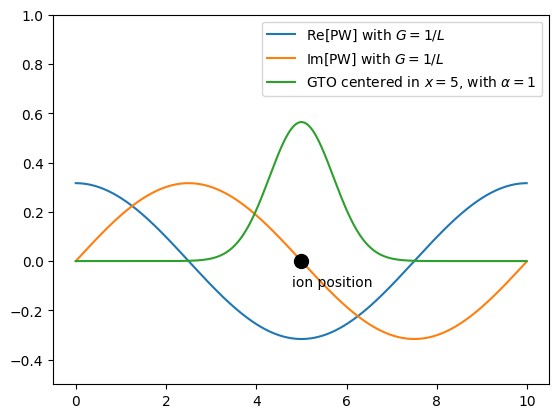

In [9]:
fig = plt.figure(figsize=(8,5))
plt.plot(X, np.real(pw(X, G=1/L)), label=r"Re[PW], $G=1/L$")
plt.plot(X, np.imag(pw(X, G=1/L)), label=r"Im[PW], $G=1/L$")
plt.plot(X, gto(X, center=5, alpha=1), label=r"GTO at $x=5$, $\alpha=1$")
plt.plot(5, 0, 'ko', markersize=8); plt.text(4.8, -0.12, "ion position")
plt.xlabel('$x$'); plt.ylabel(r'$\chi(x)$')
plt.title('A delocalized plane wave vs. a localized Gaussian')
plt.ylim([-.5, 1]); plt.legend(); plt.grid(alpha=0.3)

<center>
    <div class="alert alert-success">
        Plane waves are <b>delocalized</b> and periodic &mdash; natural for <b>solids</b>.<br>
        Gaussians are <b>localized</b> on atoms &mdash; natural for <b>molecules</b>.
    </div>
</center>

# Challenge 5

[Orthogonality of basis functions](https://forms.cloud.microsoft/r/6MkpEkXKhW)
 
 The condition for orthonormality $S_{ij}=\langle \chi_i | \chi_j\rangle = \delta_{ij}$.
 
 <center><img src="../figures/random/QR_Challenge5.png" width=500 height=300 /></center>
 

# Solution to Challenge 5: orthonormality

**Criterion.** A basis is orthonormal when its overlap matrix is the identity:
$$
S_{ij} = \langle \chi_i | \chi_j \rangle = \int \chi_i^*(r)\,\chi_j(r)\,dr = \delta_{ij}.
$$

**Plane waves** $\chi_G(r) = \tfrac{1}{\sqrt{\Omega}} e^{iG\cdot r}$:
$$
S_{GG'} = \frac{1}{\Omega}\int_\Omega e^{\,i(G'-G)\cdot r}\, dr = \delta_{GG'}.
$$
The integral gives $1$ when $G=G'$ (the $1/\sqrt{\Omega}$ normalizes it) and $0$ otherwise, since a full-period exponential averages to zero.

<center><div class="alert alert-success">
<b>Yes &mdash; plane waves are orthonormal</b>, so $\mathbb{S}=\mathbb{I}$.
</div></center>

**GTOs** $\chi_i = e^{-\alpha_i |r-\mu_i|^2}$: the product of two Gaussians is another Gaussian, whose integral is **always positive** and only vanishes when the centers are infinitely far apart. Each one can be normalized ($S_{ii}=1$), but the off-diagonal $S_{ij}$ can't be made zero.

<center><div class="alert alert-danger">
<b>No &mdash; GTOs are not orthonormal</b> ($S_{ij}\neq 0$ in general).
</div></center>

**Why it matters:** in $\mathbb{HC}=\mathbb{SC\varepsilon}$, plane waves give $\mathbb{S}=\mathbb{I}$ (an ordinary eigenvalue problem), while GTOs give $\mathbb{S}\neq\mathbb{I}$ (a *generalized* one).

## Why this matters

This is exactly the origin of the overlap matrix in $\;\mathbb{HC}=\mathbb{SC\varepsilon}$:
- **PW:** $\mathbb{S}=\mathbb{I}$ &rarr; an ordinary eigenvalue problem $\mathbb{HC}=\mathbb{C\varepsilon}$.
- **GTO:** $\mathbb{S}\neq\mathbb{I}$ &rarr; a genuine *generalized* eigenvalue problem (one must handle $\mathbb{S}$, e.g. via Löwdin orthogonalization).

# How many plane waves are needed?

In [1]:
qe_options = {}
qe_options["&electrons"] = {}
qe_options["&electrons"]["ecutwf"] = 80
qe_options["&electrons"]["ecutrho"] = 320

- `ecutwf` is the kinetic energy of the PW with the largest $G$ point in Ry
- `ecutrho` is the kinetic energy of the PW with the largest $G$ point used to Fourier transform the electron density $n(r)$ in Ry

# How many plane waves? Let's *see* it

A plane-wave cutoff keeps every wave with $|G| \le G_{max}$. Sharper features need larger $|G|$ &mdash; i.e. a higher cutoff.

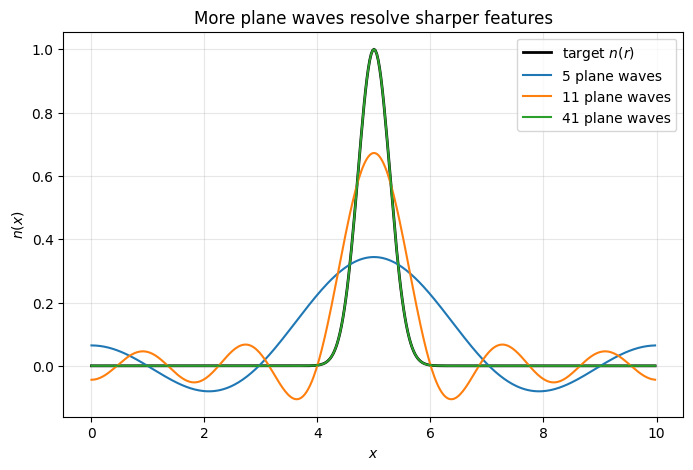

In [5]:
import numpy as np
import matplotlib.pyplot as plt
L = 10.0
x = np.linspace(0, L, 400, endpoint=False)
def target(x, x0=5.0, w=0.4):        # a localized feature in the density
    return np.exp(-((x - x0)/w)**2)
f  = target(x)
Fk = np.fft.fft(f)                    # plane-wave (Fourier) coefficients
G  = np.fft.fftfreq(len(x))           # associated |G| ordering
plt.figure(figsize=(8,5))
plt.plot(x, f, 'k', lw=2, label='target $n(r)$')
for npw in [5, 11, 41]:               # keep the npw lowest-|G| plane waves
    keep = np.argsort(np.abs(G))[:npw]
    Fk_cut = np.zeros_like(Fk); Fk_cut[keep] = Fk[keep]
    recon = np.fft.ifft(Fk_cut).real
    plt.plot(x, recon, label=f'{npw} plane waves')
plt.xlabel('$x$'); plt.ylabel('$n(x)$')
plt.title('More plane waves resolve sharper features')
plt.legend(); plt.grid(alpha=0.3)

<center>
    <div class="alert alert-success">
        Too few plane waves $\Rightarrow$ ripples (can't resolve the feature).
        A narrower bump needs a <b>higher</b> <code>ecutwfc</code> &mdash; that is exactly what the cutoff controls.
    </div>
</center>

# Challenge 6

[Atomic units conversion](https://forms.cloud.microsoft/r/UnWr1CsP9j)

 <center><img src="../figures/random/QR_Challenge6.png" width=500 height=300 /></center>


# How do basis sets "discretize" the KS equations?

<br>
Working with your group mates, discretize the KS equations 
$$-\frac{1}{2}\nabla^2 \phi_k(r) + v_s(r) \phi_k(r) = \varepsilon_k \phi_k(r)$$

<div class="alert alert-success"> 
        Use: $\{\chi_i(r)\}$ such that $\phi_k(r) = \sum_i C_{ik} \chi_i(r)$ 
</div>

<div class="alert alert-success"> 
        Consider: KS Hamiltonian matrix elements are $H_{ji}=\langle \chi_j | \hat H | \chi_i \rangle$ and the overlap elements among the basis functions are $S_{ji}=\langle \chi_j|\chi_i\rangle$.
</div>

# Discretized KS equations

The final result should be 

$$
\sum_i H_{ji}C_{ik} = \varepsilon_k \sum_i S_{ji} C_{ik}
$$ 

or in matrix form

<div style="font-size: 170%;">
$$
\color{green}{\mathbb{HC}=\mathbb{SC\varepsilon}}
$$
</div>



 - $\mathbb{H}$: The KS Hamiltonian, mean field Hamiltonian or Fock matrix
 - $\mathbb{C}$: The matrix of the coefficients. Each column represents a KS orbital. In PW, these are simply the `bands`
 - $\varepsilon$: A diagonal matrix with the orbital energies, $\varepsilon_k$. Also KS eigenvalues, ...
 - $\mathbb{S}$: Overlap matrix. Diagonal in PW.

# Now we can solve  $\mathbb{HC=C\varepsilon}$?

$$
H_{ij} =  \left[ \frac{G_i^2}{2} \delta_{ij} + \frac{1}{\Omega}\tilde v_s(G_j - G_i) \right] \\ 
\text{ ... and ... } S_{ij} = \delta_{ij}
$$

Remember $v_s(r) = v_{eN}(r) + v_H(r) + v_{xc}(r)$.

<div class="alert alert-warning">
    <h4>Is it enough? </h4>
</div>

<div class="alert alert-warning">
    <h4>$v_H$ and $v_{xc}$ depend on $n(r)$. Do we know what $n(r)$ is?</h4>
</div>

<center><div class="alert alert-success">
    <h4>We'll get to this later</h4>
</div></center>

<div id="bg-slide">
<br><br>
<center>
<span style="font-size:34pt;"><b>Part 3</b></span>
<br><br>
<h1>The SCF cycle</h1>
<br>
<h3>Solving $\mathbb{HC=SC\varepsilon}$ self-consistently</h3>
</center>
<br><br>
</div>

### How can we solve it?
<br>
<center> <div class="alert alert-success"> <b><a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.eigh.html#scipy.linalg.eigh">Generalized eigenvalue problem</a></b></div></center>

# $\mathbb{H}$ depends on $v_s(r)$ which depends on $n(r)$

<center> <div class="alert alert-warning"> <b>What $n(r)$ should we use to evaluate $\mathbb{H}$?</b></div></center>

 - uniform density

 - sum of atomic densities (SAD), usually taken from the pseudopotential

<center><img src="../figures/science/sad.png" width=600 /></center>

<center> <div class="alert alert-danger"> <b>But this is only a guess...</b></div></center>

# A chicken-and-egg problem

 - To build $\mathbb{H}[n]$ we need the density $n(r)$.
 - But $n(r)$ comes from the orbitals we get by *solving* $\mathbb{HC}=\mathbb{SC\varepsilon}$.
 - Neither is available first.

<center>
    <div class="alert alert-success">
        Resolve it by <b>iteration</b>: guess $\to$ solve $\to$ rebuild $\to$ repeat until $n(r)$ stops changing.<br>
        That fixed point is the <b>self-consistent</b> solution.
    </div>
</center>

# The Self-Consistent Field (SCF) loop

<center><img src="../figures/science/scf.png" width=800 /></center>

# What does convergence look like?

A toy self-consistent map $n_{out}=F(n_{in})$ with a fixed point $n^*$. Watch what feeding the output straight back does &mdash; and how **mixing** fixes it.

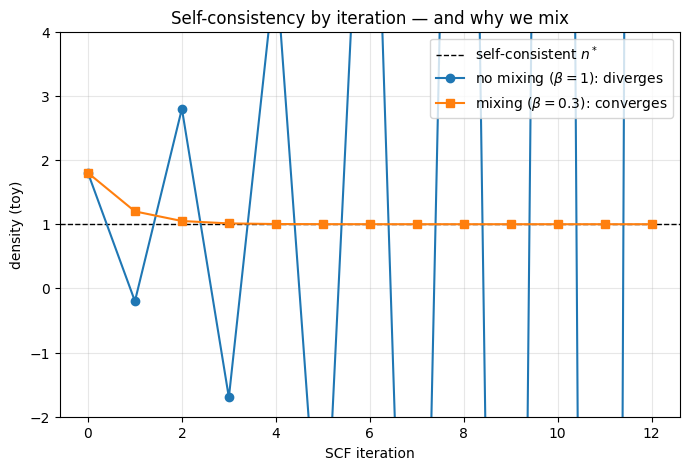

In [6]:
import numpy as np
import matplotlib.pyplot as plt
nstar = 1.0                                   # the self-consistent density n*
def solve_and_rebuild(n, slope=-1.5):         # toy "solve KS + rebuild density"
    return nstar + slope*(n - nstar)
n0 = 1.8
def run(beta, steps=12):                       # linear density mixing
    n = n0; hist = [n]
    for _ in range(steps):
        n_out = solve_and_rebuild(n)
        n = (1 - beta)*n + beta*n_out
        hist.append(n)
    return hist
plt.figure(figsize=(8,5))
plt.axhline(nstar, color='k', ls='--', lw=1, label='self-consistent $n^*$')
plt.plot(run(1.0), 'o-', label=r'no mixing ($\beta=1$): diverges')
plt.plot(run(0.3), 's-', label=r'mixing ($\beta=0.3$): converges')
plt.xlabel('SCF iteration'); plt.ylabel('density (toy)')
plt.ylim(-2, 4); plt.title('Self-consistency by iteration — and why we mix')
plt.legend(); plt.grid(alpha=0.3)

# Density mixing

Instead of feeding $n_{out}$ straight back, mix it with the input:

<div style="font-size:130%;">
$$
n_{in}^{(i+1)} = (1-\beta)\, n_{in}^{(i)} + \beta\, n_{out}^{(i)}
$$
</div>

 - $\beta$ is the **mixing parameter** (often $0.1$&ndash;$0.7$; QE: `mixing_beta`).
 - It damps oscillations and stabilizes convergence.
 - Smarter schemes (Broyden / Pulay / DIIS) accelerate it further.

<center>
    <div class="alert alert-success">
        Good mixing can turn a <b>diverging</b> SCF into a <b>converging</b> one &mdash; exactly as we just saw.
    </div>
</center>

# In QEpy and QE, the SCF is a basic workflow

 - QE handles it via the card `&control`

 - QEpy via the equivalent card in the options dictionary, like this:

In [2]:
qe_options = {}
qe_options['&control'] = {}
qe_options['&control']['calculation'] = 'scf'

# The SCF threshold

$\tau$ usually is in units of energy. Appropriate convergence conditions are

<center> <div class="alert alert-success">$$\int |n_{in}(r)-n_{out}(r)| dr < \tau$$</div></center>

<center> 
    <div class="alert alert-success">
        $$\int \frac{\big(n_{out}(r)-n_{in}(r)\big)\big(n_{out}(r')-n_{in}(r')\big)}{|r-r'|} drdr' < \tau ~~\color{red}{\to ~~ \text{this is the condition adopted by QE}}$$
    </div>
</center>

# Challenge 7: homework
 
Derive the equation to obtain the electron density from the basis functions $\{\chi_k(r)\}$ and the wavefunction coefficients $\{C_{ki}\}$. Use the expression
 
 $$
 n(r) = \sum_k^N |\phi_k(r)|^2, \text{ assume for simplicity } \phi_k(r)\in \mathbb{R}
 $$
 

# Occupation numbers

The usual equation (remember $N$ is the number of electrons)
<center> 
    <div class="alert alert-success">$$  n(r) = \sum_k^N |\phi_k(r)|^2 \to \text{aufbau}$$
    </div>
</center>

For non-zero $T$ or for small gaps ($E_g\ll 1$ where the SCF can get confused):
<center>
    <div class="alert alert-warning">$$  n(r) = \sum_k f_k |\phi_k(r)|^2 \to \sum_k f_k = N$$</div>
    <br>
    where $f_k$ are called occupation numbers
</center>

For solids, the need for $k$-points often requires smearing:
<center> 
    <div class="alert alert-danger">$$  n(r) = \sum_k \sum_{\nu \in \text{FBZ}} f_{k\nu} |\phi_{k\nu}(r)|^2 \to \sum_{k\nu} f_{k\nu} = N$$
    </div>
</center>

# Challenge 2: what are these $f_k$?

- Code your own Fermi-Dirac smearing function to generate occupation numbers $\{f_k\}$ given orbital energies $\{\varepsilon_k\}$

Consider a set of eigenvalues, $\{\varepsilon_k\}$ coming from $\color{green}{\mathbb{HC}=\mathbb{SC\varepsilon}}$. Evaluate the Fermi-Dirac distribution and impose $\sum_k f_k = N$. <i>Feel free to use AI to help you code it.</i> Justify and explain your code to a <b>tutor</b>.

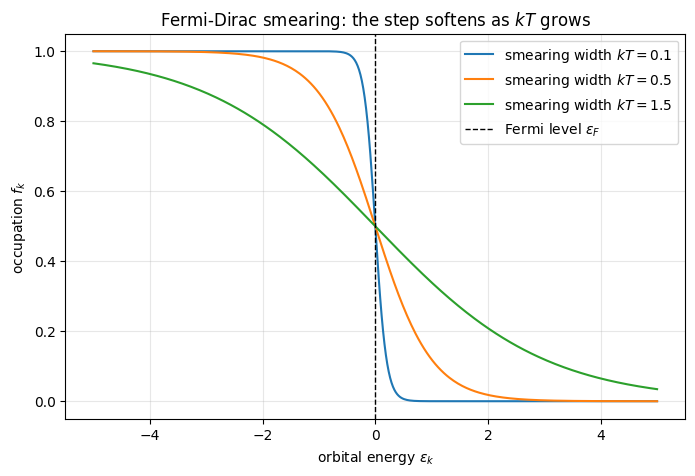

In [3]:
import numpy as np
import matplotlib.pyplot as plt

eps = np.linspace(-5, 5, 400)      # orbital energies
eF  = 0.0                          # Fermi level

plt.figure(figsize=(8,5))
for kT in [0.1, 0.5, 1.5]:         # smearing widths
    f = 1.0/(1.0 + np.exp((eps - eF)/kT))
    plt.plot(eps, f, label=f'smearing width $kT = {kT}$')
plt.axvline(eF, color='k', ls='--', lw=1, label=r'Fermi level $\varepsilon_F$')
plt.xlabel(r'orbital energy $\varepsilon_k$'); plt.ylabel(r'occupation $f_k$')
plt.title('Fermi-Dirac smearing: the step softens as $kT$ grows')
plt.legend(); plt.grid(alpha=0.3)

<center>
    <div class="alert alert-success">
        As $kT \to 0$ this recovers the sharp <b>aufbau</b> step (filled below $\varepsilon_F$, empty above).<br>
        A little smearing gives states near $\varepsilon_F$ <b>fractional</b> occupations, stabilizing the SCF for metals and small-gap systems.
    </div>
</center>

# Putting it all together

<div class="alert alert-success">
geometry &amp; pseudopotentials &nbsp;$\to$&nbsp; choose a basis (cutoff <code>ecutwfc</code>) &nbsp;$\to$&nbsp; guess $n(r)$
</div>

<div class="alert alert-warning">
<b>SCF loop:</b>&nbsp; build $\mathbb{H}[n]$ &nbsp;$\to$&nbsp; solve $\mathbb{HC}=\mathbb{SC\varepsilon}$ &nbsp;$\to$&nbsp; occupy ($f_k$) &nbsp;$\to$&nbsp; new $n(r)$ &nbsp;$\to$&nbsp; mix &nbsp;$\to$&nbsp; check $\tau$
</div>

<div class="alert alert-success">
converged $n(r)$ &nbsp;$\to$&nbsp; energy, forces, band structure, properties
</div>

<center><i>Everything in this lecture is one pass around this loop.</i></center>

<center> 
    <div class="alert alert-success">
        Now time for hands-on activities: "SCF with <b>QEpy</b>" (and have QE solve it!)
    </div>
</center>